# Baseline Models - ResNet-18 Comparison

**Research Question:** How do different pretraining sources and training strategies affect CNN performance?

## 2x2 Experimental Design:

|  | Linear Probing | Fine-Tuning |
|---|---|---|
| **ImageNet** | Model A | Model B |
| **Flowers-102** | Model C | Model D |

---

## How to Use This Notebook:

1. **Restart Kernel** (if needed)
2. **Run All "RUN EVERY TIME" cells** (Blocks 0-7)
3. **Run Training** (Block 8/9) - only once, takes ~30-60 min
4. **Run Evaluation** (Block 10) - after training completes

See the **Quick Reference** table at the bottom for details.

In [17]:
# Device-Initialisierung (GPU/CPU) und Test Loader Fallback
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import os
from pathlib import Path

# Device setzen
if 'device' not in dir():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Device gesetzt: {device}")
else:
    print(f"Device bereits gesetzt: {device}")

# Test Loader prüfen und ggf. initialisieren
test_dir = Path('./data/xAI_ImageNet1k_OwnTestSet/xai-imagenet10-hard-test')
test_available = test_dir.exists() and any(test_dir.glob('*'))

if test_available:
    test_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
    ])
    test_dataset_block9 = datasets.ImageFolder(test_dir, test_transform)
    test_loader = DataLoader(test_dataset_block9, batch_size=32, shuffle=False, num_workers=0)
    print("Test Loader erfolgreich initialisiert.")
else:
    print("❌ Testdatensatz nicht gefunden. Test Loader nicht verfügbar.")

Device bereits gesetzt: cuda
Test Loader erfolgreich initialisiert.


## Block 0 - Imports & Setup

**RUN EVERY TIME** (Run after every kernel restart)

This block loads all required libraries and configures GPU/CPU.

In [1]:
# Block 0 - Imports & Setup
# This block loads all required libraries and configures the environment

# ============ IMPORTS ============
import os                                    # Operating system utilities (file/folder operations)
import warnings                              # Control warning messages display
from torchvision import datasets, transforms, models  # Image datasets, preprocessing, pretrained models
from torch.utils.data import DataLoader      # Batch data loading for training
import torch                                 # Main PyTorch library
import torch.nn as nn                        # Neural network layers (Linear, Conv2d, etc.)
import torch.optim as optim                  # Optimizers (SGD, Adam, etc.)
import copy                                  # Deep copy for saving model weights
from pathlib import Path                     # Cross-platform file path handling
import random                                # Python random number generator
import numpy as np                           # Numerical computing library

# ============ CHECKPOINT PATH ============
# Path to flower-pretrained weights (for Model C/D)
# Located in notebooks/models/ folder
FLOWER_CKPT = "./models/flower_resnet18_state.pth"

# ============ SET SEEDS FOR REPRODUCIBILITY ============
torch.manual_seed(42)                        # PyTorch random seed
np.random.seed(42)                           # NumPy random seed
random.seed(42)                              # Python random seed

# ============ cuDNN SETTINGS ============
torch.backends.cudnn.deterministic = True    # Ensure deterministic results (same output every run)
torch.backends.cudnn.benchmark = False       # Disable auto-tuning (slower but reproducible)

# ============ SELECT DEVICE ============
if torch.cuda.is_available():                # Check if NVIDIA GPU is available
    device = torch.device('cuda')            # Use GPU for faster training
    print("✅ CUDA GPU is available! Training on CUDA...")
else:
    device = torch.device('cpu')             # Fall back to CPU
    print("⚠️ No GPU found. Training on CPU...")

print("Using device:", device)               # Print selected device

# ============ SUPPRESS WARNINGS ============
warnings.filterwarnings("ignore", message=".*cuDNN.*")  # Hide cuDNN warnings
warnings.filterwarnings("ignore", category=UserWarning, module="torch.backends.cudnn")

# ============ VERIFY FLOWER CHECKPOINT ============
flower_path = Path(FLOWER_CKPT)
if flower_path.exists():
    print(f"✅ Flower checkpoint found: {flower_path.resolve()}")
else:
    print(f"⚠️ Flower checkpoint NOT found at: {flower_path.resolve()}")
    print("   To create it, run: python scripts/train_flower_pretrain.py")
    print("   Models C and D will be skipped during training.")

✅ CUDA GPU is available! Training on CUDA...
Using device: cuda
✅ Flower checkpoint found: C:\Users\Elahe\Desktop\Repo-xAI-Proj-B\block-4-5-model-ab-fatemeh\notebooks\models\flower_resnet18_state.pth


## Block 1 - Dataset & DataLoader Setup

**RUN EVERY TIME** (Run after every kernel restart)

This block loads the datasets (Train/Val/Test).

In [2]:
#Block 1 - Dataset & DataLoader Setup
# This block loads images and prepares them for training/validation/testing

from pathlib import Path
from torchvision import transforms
from torchvision import datasets
from torch.utils.data import DataLoader

# ============ DEFINE PATHS ============
# All data is in notebooks/data/ folder
data_root = Path("./data")                    # Root folder containing all data
imagenet_root = data_root / "ImageNetSubset"  # Subfolder with ImageNet-style structure
train_dir = imagenet_root / "train"           # Training images folder (13,000 images, balanced)
val_dir = imagenet_root / "val"               # Validation images folder (500 images, balanced)
test_dir = data_root / "xAI_ImageNet1k_OwnTestSet" / "xai-imagenet10-hard-test"  # Test images (4,409 images, imbalanced)

print("train_dir:", train_dir.resolve(), "exists?", train_dir.exists())
print("val_dir  :", val_dir.resolve(),   "exists?", val_dir.exists())
print("test_dir :", test_dir.resolve(),  "exists?", test_dir.exists())

# ============ IMAGE SIZE ============
input_size = 224  # ResNet-18 expects 224x224 pixel images

# ============ DATA TRANSFORMS ============
# Transforms are preprocessing steps applied to each image
# Our augmentation pipeline includes random horizontal flipping, rotation up to 15 degrees,
# and colour jittering that affects brightness, contrast, and saturation. These transformations 
# help the model learn invariance to common real-world variations

data_transforms = {
    # Training transforms (with augmentation for better generalization)
    "train": transforms.Compose([
        transforms.Resize((input_size, input_size)),  # Resize image to 224x224
        transforms.RandomHorizontalFlip(),             # Randomly flip image left-right (50% chance)
        transforms.RandomRotation(15),                 # Randomly rotate image by +/-15 degrees
        transforms.ColorJitter(0.2, 0.2, 0.2, 0.1),   # Randomly change brightness, contrast, saturation, hue
        transforms.ToTensor(),                         # Convert PIL image to PyTorch tensor (0-255 -> 0-1)
        transforms.Normalize([0.485, 0.456, 0.406],   # Normalize using ImageNet mean values (RGB)
                             [0.229, 0.224, 0.225]),  # Normalize using ImageNet std values (RGB)
    ]),
    # Validation/Test transforms (NO augmentation - evaluate on clean images)
    "val": transforms.Compose([
        transforms.Resize((input_size, input_size)),  # Resize image to 224x224
        transforms.ToTensor(),                         # Convert to tensor
        transforms.Normalize([0.485, 0.456, 0.406],   # Same normalization as training
                             [0.229, 0.224, 0.225]),
    ]),
}

# ============ HELPER FUNCTION ============
def has_images(directory: Path):
    """Check if a directory contains any JPG/JPEG/PNG images"""
    if not directory.exists():        # If folder doesn't exist, return False
        return False
    valid_extensions = {".jpg", ".jpeg", ".JPG", ".JPEG", ".png", ".PNG"}  # Accepted file types
    for f in directory.rglob("*"):    # Search all files recursively
        if f.suffix in valid_extensions:  # Check file extension
            return True               # Found at least one image
    return False                      # No images found

# ============ LOAD DATASETS ============
# Check if real images exist, otherwise use fake data for testing
if has_images(train_dir) and has_images(val_dir):
    # Real dataset found - use ImageFolder
    print("Using real ImageNetSubset dataset (ImageFolder)")

    image_datasets = {
        # ImageFolder automatically assigns labels based on subfolder names
        "train": datasets.ImageFolder(train_dir, data_transforms["train"]),
        "val": datasets.ImageFolder(val_dir, data_transforms["val"]),
    }
    num_classes = len(image_datasets["train"].classes)  # Count number of class folders
    class_names = image_datasets["train"].classes       # Get list of class names

    # ============ LOAD TEST SET (if exists) ============
    if has_images(test_dir):
        image_datasets["test"] = datasets.ImageFolder(test_dir, data_transforms["val"])
        print("Test set loaded from xAI_ImageNet1k_OwnTestSet")
    else:
        print("WARNING: Test set not found at", test_dir.resolve())

else:
    # No real data - use FakeData for pipeline testing
    print("WARNING: No real dataset found. Using FakeData for pipeline validation.")

    num_classes = 10                                    # Simulate 10 classes
    class_names = [f"class_{i}" for i in range(num_classes)]  # Generate fake class names
    image_datasets = {
        "train": datasets.FakeData(
            size=64,                                    # 64 fake training samples
            image_size=(3, input_size, input_size),    # 3 channels (RGB), 224x224
            num_classes=num_classes,                   # 10 classes
            transform=data_transforms["train"],        # Apply training transforms
        ),
        "val": datasets.FakeData(
            size=32,                                    # 32 fake validation samples
            image_size=(3, input_size, input_size),
            num_classes=num_classes,
            transform=data_transforms["val"],          # Apply validation transforms
        ),
        "test": datasets.FakeData(
            size=64,                                    # 64 fake test samples
            image_size=(3, input_size, input_size),    # 3 channels (RGB), 224x224
            num_classes=num_classes,                   # 10 classes
            transform=data_transforms["val"],          # Apply validation transforms (no augmentation)
        ),
    }

# ============ CREATE DATALOADERS ============
batch_size = 32   # Number of images per batch (GPU processes 32 images at once)

# num_workers = number of parallel processes for data loading
# 0 = load data in main process (most stable for notebooks)
num_workers = 0

dataloader = {
    # Training DataLoader - shuffle=True randomizes order each epoch
    "train": DataLoader(
        image_datasets["train"],
        batch_size=batch_size,
        shuffle=True,           # Shuffle training data for better learning
        num_workers=num_workers
    ),
    # Validation DataLoader - shuffle=False keeps order consistent
    "val": DataLoader(
        image_datasets["val"],
        batch_size=batch_size,
        shuffle=False,          # No shuffle for validation (reproducible results)
        num_workers=num_workers
    ),
}

# Add test DataLoader if test set exists
if "test" in image_datasets:
    dataloader["test"] = DataLoader(
        image_datasets["test"],
        batch_size=batch_size,
        shuffle=False,          # No shuffle for test (reproducible results)
        num_workers=num_workers
    )

# ============ PRINT SUMMARY ============
print("\n" + "="*50)
print("DATASET SUMMARY")
print("="*50)
print(f"Train samples:      {len(image_datasets['train']):,}")
print(f"Validation samples: {len(image_datasets['val']):,}")
if "test" in image_datasets:
    print(f"Test samples:       {len(image_datasets['test']):,}")
print(f"Num classes:        {num_classes}")
print(f"Classes:            {class_names}")
print("="*50)

train_dir: C:\Users\Elahe\Desktop\Repo-xAI-Proj-B\block-4-5-model-ab-fatemeh\notebooks\data\ImageNetSubset\train exists? True
val_dir  : C:\Users\Elahe\Desktop\Repo-xAI-Proj-B\block-4-5-model-ab-fatemeh\notebooks\data\ImageNetSubset\val exists? True
test_dir : C:\Users\Elahe\Desktop\Repo-xAI-Proj-B\block-4-5-model-ab-fatemeh\notebooks\data\xAI_ImageNet1k_OwnTestSet\xai-imagenet10-hard-test exists? True
Using real ImageNetSubset dataset (ImageFolder)
Test set loaded from xAI_ImageNet1k_OwnTestSet

DATASET SUMMARY
Train samples:      13,000
Validation samples: 500
Test samples:       4,409
Num classes:        10
Classes:            ['binder', 'coffee_mug', 'computer_keyboard', 'mouse', 'notebook', 'remote_control', 'soup_bowl', 'teapot', 'toilet_tissue', 'wooden_spoon']


## Block 2 - Training Function

**RUN EVERY TIME** (Run after every kernel restart)

Defines the `train_model()` function for training models.

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import copy

 #Block 2 - Training Function
# This function trains any model and returns the best version based on validation accuracy

def train_model(
    model,                                     # The neural network model to train
    train_loader,                                   # DataLoader for training data
    val_loader,                                      # DataLoader for validation data
    device,                                          # 'cuda' or 'cpu'
    num_epochs,                                       # Number of training epochs
    lr=1e-4,                                          # Learning rate (default: 0.0001)
    save_path="./models/best_model.pth",    # Path to save best model weights
):
    """
    Generic training loop for a classification model.
    Returns: model, best_acc, history
    """
    
    # ============ SETUP ============
    model = model.to(device)                 # Move model to GPU/CPU
    
    # ╔═══════════════════════════════════════════════════════════════════════╗
    # ║  📍 OPERATION 6: DEFINE LOSS FUNCTION                                 ║
    # ║  تعریف تابع Loss برای محاسبه خطا                                      ║
    # ╚═══════════════════════════════════════════════════════════════════════╝
    criterion = nn.CrossEntropyLoss()        # Loss function for classification
    
    # ╔═══════════════════════════════════════════════════════════════════════╗
    # ║  📍 OPERATION 7: DEFINE OPTIMIZER                                     ║
    # ║  تعریف Optimizer برای به‌روزرسانی وزن‌ها                              ║
    # ╚═══════════════════════════════════════════════════════════════════════╝
    optimizer = optim.SGD(                   # SGD optimizer with momentum
        filter(lambda p: p.requires_grad, model.parameters()),  # Only trainable params
        lr=lr,                               # Learning rate
        momentum=0.9,                        # Momentum for faster convergence
    )

    dataset_sizes = {                        # Store dataset sizes for averaging
        "train": len(train_loader.dataset),
        "val": len(val_loader.dataset),
    }

    best_acc = 0.0                           # Track best validation accuracy
    best_state = copy.deepcopy(model.state_dict())  # Save initial weights

    history = {                              # Store metrics for plotting
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
    }

    # ============ TRAINING LOOP ============
    for epoch in range(num_epochs):          # Loop through epochs
        print(f"\nEpoch {epoch+1}/{num_epochs}")

        # ======== TRAIN PHASE ========
        model.train()                        # Set model to training mode (enables dropout, batchnorm)
        running_loss = 0.0                   # Accumulate loss for this epoch
        running_corrects = 0                 # Accumulate correct predictions

        for inputs, labels in train_loader:  # Loop through batches
            inputs = inputs.to(device)       # Move images to GPU/CPU
            labels = labels.to(device)       # Move labels to GPU/CPU

            optimizer.zero_grad(set_to_none=True)  # Clear previous gradients

            # ╔═══════════════════════════════════════════════════════════════╗
            # ║  📍 OPERATION 8: FORWARD PASS                                 ║
            # ║  مدل تصاویر را می‌بیند و پیش‌بینی می‌کند                       ║
            # ╚═══════════════════════════════════════════════════════════════╝
            outputs = model(inputs)          # Forward pass: get predictions
            
            # ╔═══════════════════════════════════════════════════════════════╗
            # ║  📍 OPERATION 9: CALCULATE LOSS                               ║
            # ║  محاسبه میزان خطای پیش‌بینی                                    ║
            # ╚═══════════════════════════════════════════════════════════════╝
            loss = criterion(outputs, labels)  # Calculate loss
            _, preds = torch.max(outputs, 1)  # Get predicted class (highest score)

            # ╔═══════════════════════════════════════════════════════════════╗
            # ║  📍 OPERATION 10: BACKWARD PASS (Backpropagation)             ║
            # ║  محاسبه گرادیان‌ها - مدل یاد می‌گیرد چگونه بهتر شود            ║
            # ╚═══════════════════════════════════════════════════════════════╝
            loss.backward()                  # Backward pass: compute gradients
            
            # ╔═══════════════════════════════════════════════════════════════╗
            # ║  📍 OPERATION 11: UPDATE WEIGHTS                              ║
            # ║  به‌روزرسانی وزن‌های مدل بر اساس گرادیان‌ها                    ║
            # ╚═══════════════════════════════════════════════════════════════╝
            optimizer.step()                 # Update weights

            running_loss += loss.item() * inputs.size(0)  # Accumulate weighted loss
            
            # ╔═══════════════════════════════════════════════════════════════╗
            # ║  📍 OPERATION 12: CALCULATE ACCURACY (Training)               ║
            # ║  شمارش پیش‌بینی‌های درست                                       ║
            # ╚═══════════════════════════════════════════════════════════════╝
            running_corrects += (preds == labels).sum().item()  # Count correct predictions

        # Calculate epoch averages
        train_epoch_loss = running_loss / dataset_sizes["train"]
        train_epoch_acc = running_corrects / dataset_sizes["train"]
        history["train_loss"].append(train_epoch_loss)
        history["train_acc"].append(train_epoch_acc)

        print(f"train  Loss: {train_epoch_loss:.4f}  Acc: {train_epoch_acc:.4f}")

        # ======== VALIDATION PHASE ========
        model.eval()                         # Set model to evaluation mode (disables dropout)
        running_loss = 0.0
        running_corrects = 0

        with torch.no_grad():                # Disable gradient computation (faster, saves memory)
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)      # Forward pass only (no backprop)
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)

                running_loss += loss.item() * inputs.size(0)
                running_corrects += (preds == labels).sum().item()

        # Calculate validation averages
        val_epoch_loss = running_loss / dataset_sizes["val"]
        val_epoch_acc = running_corrects / dataset_sizes["val"]
        history["val_loss"].append(val_epoch_loss)
        history["val_acc"].append(val_epoch_acc)

        print(f"val    Loss: {val_epoch_loss:.4f}  Acc: {val_epoch_acc:.4f}")

        # ╔═══════════════════════════════════════════════════════════════════╗
        # ║  📍 OPERATION 13: SAVE BEST MODEL                                 ║
        # ║  ذخیره بهترین مدل بر اساس دقت Validation                          ║
        # ╚═══════════════════════════════════════════════════════════════════╝
        if val_epoch_acc > best_acc:         # If this epoch is the best so far
            best_acc = val_epoch_acc         # Update best accuracy
            best_state = copy.deepcopy(model.state_dict())  # Save weights
            torch.save(best_state, save_path)  # Save to disk
            print(f"  ↳ New best! Saved to {save_path}")

    # ============ FINISH ============
    print(f"\nBest val Acc: {best_acc:.4f}")
    model.load_state_dict(best_state)        # Load best weights into model

    return model, best_acc, history          # Return trained model and metrics

print("✅ train_model() function defined successfully.")#

✅ train_model() function defined successfully.


## Block 2.5 - Test Evaluation Function

**RUN EVERY TIME** (Run after every kernel restart)

Defines `evaluate_on_test()` and `print_test_results()` functions for Test Set evaluation.

In [4]:
# Test GPU is being used

print(f"Device: {device}")
print(f"CUDA available: {torch.cuda.is_available()}")

if device.type == 'cuda':
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
    
    # Test tensor on GPU
    test = torch.tensor([1.0, 2.0], device=device)
    print(f"Test tensor on: {test.device}")
    print("✅ GPU is working!")
else:
    print("❌ Using CPU, not GPU")

Device: cuda
CUDA available: True
GPU name: NVIDIA GeForce RTX 5060 Ti
GPU memory: 15.9 GB
Test tensor on: cuda:0
✅ GPU is working!


In [5]:
# Block 2.5 - Test Evaluation Function
# This function evaluates a trained model on the test set

def evaluate_on_test(model, test_loader, device, class_names=None):
    """
    Evaluate a trained model on the test set.
    
    Args:
        model: Trained PyTorch model
        test_loader: DataLoader for test data
        device: 'cuda' or 'cpu'
        class_names: Optional list of class names for per-class accuracy
        
    Returns:
        dict: Contains overall accuracy, per-class accuracy, and predictions
    """
    model = model.to(device)
    model.eval()
    
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            # ╔═══════════════════════════════════════════════════════════════╗
            # ║  📍 OPERATION 8: FORWARD PASS (Test Phase)                    ║
            # ║  مدل تصاویر تست را می‌بیند و پیش‌بینی می‌کند                   ║
            # ╚═══════════════════════════════════════════════════════════════╝
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    
    # ╔═══════════════════════════════════════════════════════════════════════╗
    # ║  📍 OPERATION 12: CALCULATE ACCURACY (Test Phase)                     ║
    # ║  محاسبه دقت کلی و دقت هر کلاس                                         ║
    # ╚═══════════════════════════════════════════════════════════════════════╝
    # Overall accuracy
    correct = (all_preds == all_labels).sum()
    total = len(all_labels)
    overall_acc = correct / total
    
    # Per-class accuracy
    num_classes = len(np.unique(all_labels))
    per_class_acc = {}
    for c in range(num_classes):
        mask = all_labels == c
        if mask.sum() > 0:
            class_correct = (all_preds[mask] == all_labels[mask]).sum()
            class_total = mask.sum()
            class_acc = class_correct / class_total
            class_name = class_names[c] if class_names else f"class_{c}"
            per_class_acc[class_name] = {
                "accuracy": class_acc,
                "correct": int(class_correct),
                "total": int(class_total)
            }
    
    results = {
        "overall_accuracy": overall_acc,
        "correct": int(correct),
        "total": int(total),
        "per_class_accuracy": per_class_acc,
        "predictions": all_preds,
        "labels": all_labels,
        "probabilities": all_probs
    }
    
    return results


def print_test_results(results, model_name="Model"):
    """Print formatted test results."""
    print(f"\n{'='*60}")
    print(f"TEST SET EVALUATION: {model_name}")
    print(f"{'='*60}")
    print(f"Overall Accuracy: {results['overall_accuracy']*100:.2f}% ({results['correct']}/{results['total']})")
    print(f"\nPer-Class Accuracy:")
    print(f"{'-'*60}")
    for class_name, stats in results['per_class_accuracy'].items():
        print(f"  {class_name:25s}: {stats['accuracy']*100:6.2f}% ({stats['correct']:3d}/{stats['total']:3d})")
    print(f"{'='*60}")


print("Test evaluation functions defined: evaluate_on_test(), print_test_results()")

Test evaluation functions defined: evaluate_on_test(), print_test_results()


## Block 3 - Flower Pretrained Backbone (Documentation)

**READ ONLY** (Documentation only - no need to run)

Explains how `flower_resnet18_state.pth` was created:
- Dataset: Oxford Flowers-102 (102 flower classes)
- Architecture: ResNet-18 with ImageNet initial weights
- Training: 15 epochs on Flowers-102
- Saved: Backbone only (without fc layer)

## Block 4 - Model A (ImageNet + Linear Probing)

**RUN EVERY TIME** (Run after every kernel restart)

Defines the `create_model_A()` function:
- Initial weights: ImageNet-1K pretrained
- Strategy: Linear Probing (only FC layer is trained)
- Trainable parameters: ~5,130

In [6]:
# Block 4 - Model A (ImageNet Pretrained, Backbone Frozen)
# This model uses pretrained ImageNet weights but only trains the final layer (Linear Probing)

from torchvision.models import ResNet18_Weights  # Import pretrained weight options

def create_model_A(num_classes):
    """
    Model A: Linear Probing
    - Use pretrained ResNet-18 backbone (frozen)
    - Only train the new classification layer
    """
    
    # ╔═══════════════════════════════════════════════════════════════════════╗
    # ║  📍 OPERATION 1: MODEL CREATION (Load Pretrained Weights)             ║
    # ║  ساخت مدل ResNet-18 با وزن‌های آموزش‌دیده ImageNet                    ║
    # ╚═══════════════════════════════════════════════════════════════════════╝
    weights = ResNet18_Weights.IMAGENET1K_V1   # Use ImageNet-1K pretrained weights (version 1)
    model = models.resnet18(weights=weights)   # Load ResNet-18 with these weights

    # ╔═══════════════════════════════════════════════════════════════════════╗
    # ║  📍 OPERATION 2: REPLACE FINAL LAYER                                  ║
    # ║  جایگزینی لایه آخر (1000 کلاس → 10 کلاس)                              ║
    # ╚═══════════════════════════════════════════════════════════════════════╝
    in_features = model.fc.in_features         # Get input size of original fc layer (512 for ResNet-18)
    model.fc = nn.Linear(in_features, num_classes)  # Replace fc: 512 → num_classes (10)

    # ╔═══════════════════════════════════════════════════════════════════════╗
    # ║  📍 OPERATION 3: FREEZE LAYERS (Linear Probing)                       ║
    # ║  فریز کردن لایه‌های backbone - فقط لایه fc آموزش می‌بیند              ║
    # ╚═══════════════════════════════════════════════════════════════════════╝
    for name, param in model.named_parameters():  # Loop through all parameters
        if not name.startswith("fc."):         # If parameter is NOT in fc layer
            param.requires_grad = False        # Freeze it (no gradient updates)
    # Result: Only fc.weight and fc.bias are trainable (~5,130 params)
    # Backbone (~11M params) stays frozen with ImageNet features

    print("Model A: ImageNet-pretrained backbone frozen (linear probe).")
    return model.to(device)                    # Move model to GPU/CPU

print("✅ create_model_A() function defined successfully.")

✅ create_model_A() function defined successfully.


## Block 5 - Model B (ImageNet + Fine-Tuning)

**RUN EVERY TIME** (Run after every kernel restart)

Defines the `create_model_B()` function:
- Initial weights: ImageNet-1K pretrained
- Strategy: Fine-Tuning (all layers are trained)
- Trainable parameters: ~11M

In [7]:
# Block 5 - Model B (ImageNet Pretrained, Full Fine-Tuning)
# This model uses pretrained ImageNet weights and trains ALL layers (Fine-Tuning)

def create_model_B(num_classes):
    """
    Model B: Full Fine-Tuning
    - Use pretrained ResNet-18 backbone (trainable)
    - Train the entire network including backbone
    """
    
    # ╔═══════════════════════════════════════════════════════════════════════╗
    # ║  📍 OPERATION 1: MODEL CREATION (Load Pretrained Weights)             ║
    # ║  ساخت مدل ResNet-18 با وزن‌های آموزش‌دیده ImageNet                    ║
    # ╚═══════════════════════════════════════════════════════════════════════╝
    weights = ResNet18_Weights.IMAGENET1K_V1   # Use ImageNet-1K pretrained weights
    model = models.resnet18(weights=weights)   # Load ResNet-18 with these weights

    # ╔═══════════════════════════════════════════════════════════════════════╗
    # ║  📍 OPERATION 2: REPLACE FINAL LAYER                                  ║
    # ║  جایگزینی لایه آخر (1000 کلاس → 10 کلاس)                              ║
    # ╚═══════════════════════════════════════════════════════════════════════╝
    in_features = model.fc.in_features         # Get input size of original fc layer (512)
    model.fc = nn.Linear(in_features, num_classes)  # Replace fc: 512 → num_classes (10)

    # ╔═══════════════════════════════════════════════════════════════════════╗
    # ║  📍 OPERATION 4: UNFREEZE ALL LAYERS (Fine-Tuning)                    ║
    # ║  آزاد کردن همه لایه‌ها - کل مدل آموزش می‌بیند                         ║
    # ╚═══════════════════════════════════════════════════════════════════════╝
    for name, param in model.named_parameters():  # Loop through all parameters
        param.requires_grad = True             # Make ALL parameters trainable
    # Result: All ~11M parameters are trainable
    # Backbone adapts to new task (can learn task-specific features)
    # Requires smaller learning rate to avoid destroying pretrained features

    print("Model B: ImageNet-pretrained backbone trainable (fine-tuning).")
    return model.to(device)                    # Move model to GPU/CPU

print("✅ create_model_B() function defined successfully.")

✅ create_model_B() function defined successfully.


## Block 6 - Model C (Flowers + Linear Probing)

**RUN EVERY TIME** (Run after every kernel restart)

Defines the `create_model_C()` function:
- Initial weights: Flowers-102 pretrained
- Strategy: Linear Probing (only FC layer is trained)
- Trainable parameters: ~5,130

In [8]:
# Block 6 - Model C (Flower Pretrained, Backbone Frozen / Linear Probing)

def create_model_C(num_classes):
    """
    Model C: Linear Probing with Flower-Pretrained Weights
    
    Architecture: ResNet-18
    Initialization: Flower-pretrained checkpoint (domain-specific transfer learning)
    Training mode: Linear Probing (only fc layer trainable, backbone frozen)
    
    Args:
        num_classes (int): Number of output classes for classification
        
    Returns:
        model: ResNet-18 model with frozen backbone, ready for linear probing
    """
    
    # ╔═══════════════════════════════════════════════════════════════════════╗
    # ║  📍 OPERATION 1: MODEL CREATION (Empty Model)                         ║
    # ║  ساخت مدل خالی ResNet-18 بدون وزن‌های از پیش آموزش‌دیده               ║
    # ╚═══════════════════════════════════════════════════════════════════════╝
    model = models.resnet18(weights=None)

    # ╔═══════════════════════════════════════════════════════════════════════╗
    # ║  📍 OPERATION 5: LOAD FLOWERS WEIGHTS                                 ║
    # ║  بارگذاری وزن‌های آموزش‌دیده روی دیتاست Flowers-102                   ║
    # ╚═══════════════════════════════════════════════════════════════════════╝
    raw_state = torch.load(FLOWER_CKPT, map_location="cpu")

    # Step 2.1: Handle 'module.' prefix from DataParallel
    if any(k.startswith("module.") for k in raw_state.keys()):
        state = {k.replace("module.", "", 1): v for k, v in raw_state.items()}
    else:
        state = raw_state

    # Step 3: Remove fc weights → load backbone only
    state_no_fc = {k: v for k, v in state.items() if not k.startswith("fc.")}
    missing, unexpected = model.load_state_dict(state_no_fc, strict=False)

    print("Loaded flower-pretrained backbone (without fc).")
    print(f"  Missing keys: {missing}")        # Expected: ['fc.weight', 'fc.bias']
    print(f"  Unexpected keys: {unexpected}")  # Expected: []

    # ╔═══════════════════════════════════════════════════════════════════════╗
    # ║  📍 OPERATION 2: REPLACE FINAL LAYER                                  ║
    # ║  جایگزینی لایه آخر (102 کلاس گل → 10 کلاس)                            ║
    # ╚═══════════════════════════════════════════════════════════════════════╝
    in_features = model.fc.in_features         # 512 for ResNet-18
    model.fc = nn.Linear(in_features, num_classes)

    # ╔═══════════════════════════════════════════════════════════════════════╗
    # ║  📍 OPERATION 3: FREEZE LAYERS (Linear Probing)                       ║
    # ║  فریز کردن لایه‌های backbone - فقط لایه fc آموزش می‌بیند              ║
    # ╚═══════════════════════════════════════════════════════════════════════╝
    for name, param in model.named_parameters():
        if not name.startswith("fc."):
            param.requires_grad = False

    print("Model C: Flower-pretrained backbone frozen (linear probe).")
    return model.to(device)

print("✅ create_model_C() function defined successfully.")

✅ create_model_C() function defined successfully.


## Block 7 - Model D (Flowers + Fine-Tuning)

**RUN EVERY TIME** (Run after every kernel restart)

Defines the `create_model_D()` function:
- Initial weights: Flowers-102 pretrained
- Strategy: Fine-Tuning (all layers are trained)
- Trainable parameters: ~11M

In [9]:
# Block 7 - Model D (Flower Pretrained, Full Fine-Tuning)
# This model uses flower-pretrained weights and trains ALL layers (Fine-Tuning)

def create_model_D(num_classes):
    """
    Model D: Full Fine-Tuning with Flower Pretrained Weights
    - Use ResNet-18 backbone pretrained on flower dataset
    - Train the entire network including backbone
    """
    
    # ╔═══════════════════════════════════════════════════════════════════════╗
    # ║  📍 OPERATION 1: MODEL CREATION (Empty Model)                         ║
    # ║  ساخت مدل خالی ResNet-18 بدون وزن‌های از پیش آموزش‌دیده               ║
    # ╚═══════════════════════════════════════════════════════════════════════╝
    model = models.resnet18(weights=None)      # Create ResNet-18 without any pretrained weights

    # ╔═══════════════════════════════════════════════════════════════════════╗
    # ║  📍 OPERATION 5: LOAD FLOWERS WEIGHTS                                 ║
    # ║  بارگذاری وزن‌های آموزش‌دیده روی دیتاست Flowers-102                   ║
    # ╚═══════════════════════════════════════════════════════════════════════╝
    raw_state = torch.load(FLOWER_CKPT, map_location="cpu")  # Load saved weights from disk

    # Handle 'module.' prefix (appears when model was saved with DataParallel/multi-GPU)
    if any(k.startswith("module.") for k in raw_state.keys()):
        # Remove 'module.' prefix from all keys
        state = {k.replace("module.", "", 1): v for k, v in raw_state.items()}
    else:
        state = raw_state                      # No prefix, use weights as-is

    # ============ STEP 3: LOAD BACKBONE ONLY ============
    # Remove fc layer weights - we want fresh fc for our task
    state_no_fc = {k: v for k, v in state.items() if not k.startswith("fc.")}
    
    # Load weights with strict=False (allows missing keys)
    missing, unexpected = model.load_state_dict(state_no_fc, strict=False)

    print("Loaded flower-pretrained backbone (without fc).")
    print("Missing keys:", missing)            # Expected: ['fc.weight', 'fc.bias']
    print("Unexpected keys:", unexpected)      # Expected: [] (empty)

    # ╔═══════════════════════════════════════════════════════════════════════╗
    # ║  📍 OPERATION 2: REPLACE FINAL LAYER                                  ║
    # ║  جایگزینی لایه آخر (102 کلاس گل → 10 کلاس)                            ║
    # ╚═══════════════════════════════════════════════════════════════════════╝
    in_features = model.fc.in_features         # Get input size of original fc layer (512)
    model.fc = nn.Linear(in_features, num_classes)  # Replace fc: 512 → num_classes (10)

    # ╔═══════════════════════════════════════════════════════════════════════╗
    # ║  📍 OPERATION 4: UNFREEZE ALL LAYERS (Fine-Tuning)                    ║
    # ║  آزاد کردن همه لایه‌ها - کل مدل آموزش می‌بیند                         ║
    # ╚═══════════════════════════════════════════════════════════════════════╝
    for name, param in model.named_parameters():  # Loop through all parameters
        param.requires_grad = True             # Make ALL parameters trainable
    # Result: All ~11M parameters are trainable
    # Flower-pretrained backbone adapts to new task
    # Requires smaller learning rate to avoid destroying pretrained features

    print("Model D: Flower-pretrained backbone trainable (fine-tuning).")
    return model.to(device)                    # Move model to GPU/CPU

print("✅ create_model_D() function defined successfully.")

✅ create_model_D() function defined successfully.


## Block 8 - Train All Models

**RUN ONCE** (Run only once - training takes approximately 30-60 minutes)

This block trains all 4 models and saves the results.

**Important Note:** If models have already been trained, you can skip this block and go directly to Block 9.

In [12]:
# Block 8 - Full Training & Comparison (All Models A-D)
# This block trains all 4 models and compares their performance

# ============ SETUP DATALOADERS ============
train_loader = dataloader['train']           # Get training DataLoader from Block 1
val_loader   = dataloader['val']             # Get validation DataLoader from Block 1
num_classes  = len(image_datasets['train'].classes)  # pyright: ignore[reportAttributeAccessIssue] # Get number of classes from dataset

print("Number of classes:", num_classes)     # Print number of categories (should be 10)

# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║  📍 OPERATION 14: COMPARE RESULTS (Training All Models)                   ║
# ║  آموزش همه مدل‌ها و مقایسه نتایج                                          ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

# ============ INITIALIZE RESULTS DICTIONARY ============
results = {}                                 # Store best validation accuracy for each model

# ============ MODEL A: LINEAR PROBING (ImageNet) ============
print("\n========== Training Model A ==========")
model_A = create_model_A(num_classes)        # Create Model A (ImageNet pretrained, frozen backbone)

model_A, best_acc_A, hist_A = train_model(
    model=model_A,                           # Model to train
    train_loader=train_loader,               # Training data
    val_loader=val_loader,                   # Validation data
    device=device,                           # GPU or CPU
    num_epochs=10,                           # Train for 10 epochs
    lr=1e-3,                                 # Learning rate 0.001 (higher for linear probing)
    save_path="./models/best_model_A.pth"    # Save best weights here
)
results["Model A"] = best_acc_A              # Store Model A's best accuracy

# ============ MODEL B: FINE-TUNING (ImageNet) ============
print("\n========== Training Model B ==========")
model_B = create_model_B(num_classes)        # Create Model B (ImageNet pretrained, trainable backbone)

model_B, best_acc_B, hist_B = train_model(
    model=model_B,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    num_epochs=10,
    lr=1e-4,                                 # Smaller learning rate (0.0001) for fine-tuning
    save_path="./models/best_model_B.pth"    # Prevents destroying pretrained features
)
results["Model B"] = best_acc_B              # Store Model B's best accuracy

# ============ MODELS C & D: FLOWER PRETRAINED ============
flower_ckpt_path = Path(FLOWER_CKPT)         # Convert checkpoint path to Path object

# Check if flower checkpoint exists before training Models C/D
if not flower_ckpt_path.is_file():
    # Checkpoint not found - skip Models C and D
    print(f"⚠️ Flower checkpoint not found at {flower_ckpt_path.resolve()}. Skipping Models C and D.")
    best_acc_C = best_acc_D = None           # Set accuracies to None
    hist_C = hist_D = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}  # Empty history
    results["Model C"] = best_acc_C
    results["Model D"] = best_acc_D
else:
    # ============ MODEL C: LINEAR PROBING (Flower) ============
    print("\n========== Training Model C ==========")
    model_C = create_model_C(num_classes)    # Create Model C (Flower pretrained, frozen backbone)

    model_C, best_acc_C, hist_C = train_model(
        model=model_C,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        num_epochs=10,
        lr=1e-3,                             # Higher learning rate for linear probing
        save_path="./models/best_model_C.pth"
    )
    results["Model C"] = best_acc_C          # Store Model C's best accuracy

    # ============ MODEL D: FINE-TUNING (Flower) ============
    print("\n========== Training Model D ==========")
    model_D = create_model_D(num_classes)    # Create Model D (Flower pretrained, trainable backbone)

    model_D, best_acc_D, hist_D = train_model(
        model=model_D,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        num_epochs=10,
        lr=1e-4,                             # Smaller learning rate for fine-tuning
        save_path="./models/best_model_D.pth"
    )
    results["Model D"] = best_acc_D          # Store Model D's best accuracy

# ============ SUMMARY ============
# results dict now contains: {"Model A": acc_A, "Model B": acc_B, "Model C": acc_C, "Model D": acc_D}
# hist_A/B/C/D contain training history for plotting

Number of classes: 10

========== Training Model A ==========
Model A: ImageNet-pretrained backbone frozen (linear probe).

Epoch 1/10
train  Loss: 1.0346  Acc: 0.6911
val    Loss: 0.6499  Acc: 0.7900
  ↳ New best! Saved to ./models/best_model_A.pth

Epoch 2/10
train  Loss: 0.6692  Acc: 0.7868
val    Loss: 0.5818  Acc: 0.8020
  ↳ New best! Saved to ./models/best_model_A.pth

Epoch 3/10
train  Loss: 0.6144  Acc: 0.8005
val    Loss: 0.5622  Acc: 0.8100
  ↳ New best! Saved to ./models/best_model_A.pth

Epoch 4/10
train  Loss: 0.5755  Acc: 0.8089
val    Loss: 0.5494  Acc: 0.8040

Epoch 5/10
train  Loss: 0.5533  Acc: 0.8137
val    Loss: 0.5475  Acc: 0.8280
  ↳ New best! Saved to ./models/best_model_A.pth

Epoch 6/10
train  Loss: 0.5510  Acc: 0.8125
val    Loss: 0.5617  Acc: 0.8040

Epoch 7/10
train  Loss: 0.5420  Acc: 0.8186
val    Loss: 0.5220  Acc: 0.8340
  ↳ New best! Saved to ./models/best_model_A.pth

Epoch 8/10
train  Loss: 0.5307  Acc: 0.8178
val    Loss: 0.5414  Acc: 0.8140

Epoch 9

## Block 8.5 - Load Saved Models (Skip Training)

**RUN THIS INSTEAD OF BLOCK 8** (If models are already trained)

This block loads previously saved model weights from disk.
- Use this to skip the 30-60 minute training time
- Models must have been trained at least once before (Block 8)

In [13]:
# Block 8.5 - Load Saved Models (Skip Training)
# ============================================================================
# Use this block INSTEAD of Block 8 if models have already been trained.
# This loads the saved weights from disk - takes only a few seconds!
# ============================================================================

from pathlib import Path

# ============ PATHS TO SAVED MODELS ============
# Models are saved in notebooks/models/ folder
MODEL_PATHS = {
    "A": Path("./models/best_model_A.pth"),
    "B": Path("./models/best_model_B.pth"),
    "C": Path("./models/best_model_C.pth"),
    "D": Path("./models/best_model_D.pth"),
}

# ============ INITIALIZE VARIABLES ============
model_A = model_B = model_C = model_D = None
results = {}

# ============ LOAD MODEL A ============
if MODEL_PATHS["A"].exists():
    print("Loading Model A (ImageNet + Linear Probing)...")
    model_A = create_model_A(num_classes)
    model_A.load_state_dict(torch.load(MODEL_PATHS["A"], map_location=device))
    model_A.eval()
    print(f"  ✅ Loaded from {MODEL_PATHS['A']}")
else:
    print(f"  ❌ Model A not found at {MODEL_PATHS['A']}")

# ============ LOAD MODEL B ============
if MODEL_PATHS["B"].exists():
    print("Loading Model B (ImageNet + Fine-Tuning)...")
    model_B = create_model_B(num_classes)
    model_B.load_state_dict(torch.load(MODEL_PATHS["B"], map_location=device))
    model_B.eval()
    print(f"  ✅ Loaded from {MODEL_PATHS['B']}")
else:
    print(f"  ❌ Model B not found at {MODEL_PATHS['B']}")

# ============ LOAD MODEL C ============
if MODEL_PATHS["C"].exists():
    print("Loading Model C (Flowers + Linear Probing)...")
    model_C = create_model_C(num_classes)
    model_C.load_state_dict(torch.load(MODEL_PATHS["C"], map_location=device))
    model_C.eval()
    print(f"  ✅ Loaded from {MODEL_PATHS['C']}")
else:
    print(f"  ⚠️ Model C not found at {MODEL_PATHS['C']} (Flower checkpoint may not exist)")

# ============ LOAD MODEL D ============
if MODEL_PATHS["D"].exists():
    print("Loading Model D (Flowers + Fine-Tuning)...")
    model_D = create_model_D(num_classes)
    model_D.load_state_dict(torch.load(MODEL_PATHS["D"], map_location=device))
    model_D.eval()
    print(f"  ✅ Loaded from {MODEL_PATHS['D']}")
else:
    print(f"  ⚠️ Model D not found at {MODEL_PATHS['D']} (Flower checkpoint may not exist)")

# ============ SUMMARY ============
print("\n" + "="*50)
print("LOADED MODELS SUMMARY")
print("="*50)
loaded_models = []
if model_A is not None: loaded_models.append("A")
if model_B is not None: loaded_models.append("B")
if model_C is not None: loaded_models.append("C")
if model_D is not None: loaded_models.append("D")

print(f"Models loaded: {loaded_models}")
print(f"Ready for evaluation (Block 9) and Grad-CAM (Block 10)")
print("="*50)

Loading Model A (ImageNet + Linear Probing)...
Model A: ImageNet-pretrained backbone frozen (linear probe).
  ✅ Loaded from models\best_model_A.pth
Loading Model B (ImageNet + Fine-Tuning)...
Model B: ImageNet-pretrained backbone trainable (fine-tuning).
  ✅ Loaded from models\best_model_B.pth
Loading Model C (Flowers + Linear Probing)...
Loaded flower-pretrained backbone (without fc).
  Missing keys: ['fc.weight', 'fc.bias']
  Unexpected keys: []
Model C: Flower-pretrained backbone frozen (linear probe).
  ✅ Loaded from models\best_model_C.pth
Loading Model D (Flowers + Fine-Tuning)...
Loaded flower-pretrained backbone (without fc).
Missing keys: ['fc.weight', 'fc.bias']
Unexpected keys: []
Model D: Flower-pretrained backbone trainable (fine-tuning).
  ✅ Loaded from models\best_model_D.pth

LOADED MODELS SUMMARY
Models loaded: ['A', 'B', 'C', 'D']
Ready for evaluation (Block 9) and Grad-CAM (Block 10)


In [16]:
def print_test_results(results, model_name):
    print(f"\nErgebnisse für {model_name}:")
    if isinstance(results, dict):
        if 'overall_accuracy' in results:
            print(f"Gesamte Genauigkeit: {results['overall_accuracy']*100:.2f}%")
        if 'class_accuracies' in results:
            print("Klassen-Genauigkeiten:")
            for cls, acc in results['class_accuracies'].items():
                print(f"  {cls}: {acc*100:.2f}%")
        if 'details' in results:
            print("Weitere Details:")
            print(results['details'])
    else:
        print(results)

## Block 9 - Test Set Evaluation

**RUN AFTER TRAINING** (Run after training the models)

This block evaluates the trained models on the Test Set (4,409 images).

In [14]:
# Block 9 - Test Set Evaluation (All Models)
# ============================================================================
# This block evaluates all trained models on the test set (4,409 images).
# It is SELF-CONTAINED and will load the test set if needed.
# ============================================================================

import numpy as np
import torch
from pathlib import Path
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os

# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║  📍 OPERATION 14: COMPARE RESULTS (Final Test Evaluation)                 ║
# ║  ارزیابی نهایی همه مدل‌ها روی دیتاست تست                                ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

print("="*60)
print("BLOCK 9: TEST SET EVALUATION")
print("="*60)

# ============ CHECK REQUIRED FUNCTIONS ============
if 'evaluate_on_test' not in dir():
    def evaluate_on_test(model, test_loader, device, class_names=None):
        """Evaluate a trained model on the test set."""
        model = model.to(device)
        model.eval()
        
        all_preds = []
        all_labels = []
        
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        all_preds = np.array(all_preds)
        all_labels = np.array(all_labels)
        
        correct = (all_preds == all_labels).sum()
        total = len(all_labels)
        overall_acc = correct / total
        
        per_class_acc = {}
        for c in range(len(np.unique(all_labels))):
            mask = all_labels == c
            if mask.sum() > 0:
                class_correct = (all_preds[mask] == all_labels[mask]).sum()
                class_total = mask.sum()
                class_name = class_names[c] if class_names else f"class_{c}"
                per_class_acc[class_name] = {
                    "accuracy": class_correct / class_total,
                    "correct": int(class_correct),
                    "total": int(class_total)
                }
        
        return {
            "overall_accuracy": overall_acc,
            "correct": int(correct),
            "total": int(total),
            "per_class_accuracy": per_class_acc,
        }
    print("✅ evaluate_on_test() function defined.")

if 'print_test_results' not in dir():
    def print_test_results(results, model_name="Model"):
        """Print formatted test results."""
        print(f"\n{'='*60}")
        print(f"TEST SET EVALUATION: {model_name}")
        print(f"{'='*60}")
        print(f"Overall Accuracy: {results['overall_accuracy']*100:.2f}% ({results['correct']}/{results['total']})")
        print(f"\nPer-Class Accuracy:")
        print(f"{'-'*60}")
        for class_name, stats in results['per_class_accuracy'].items():
            print(f"  {class_name:25s}: {stats['accuracy']*100:6.2f}% ({stats['correct']:3d}/{stats['total']:3d})")
        print(f"{'='*60}")
    print("✅ print_test_results() function defined.")

# ============ FIND TEST DATASET PATH ============
# Try multiple possible paths (handles running from different locations)
# Test dataset path (relative to notebooks folder)
test_dir = Path("./data/xAI_ImageNet1k_OwnTestSet/xai-imagenet10-hard-test")

if test_dir.exists():
    print(f"✅ Found test directory: {test_dir.resolve()}")
else:
    print(f"❌ Test directory not found: {test_dir.resolve()}")

# ============ LOAD TEST DATASET ============
input_size = 224
test_transform = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

test_available = False
if test_dir.exists():
    test_dataset_block9 = datasets.ImageFolder(test_dir, test_transform)
    test_loader = DataLoader(test_dataset_block9, batch_size=32, shuffle=False, num_workers=0)
    test_dataset_size = len(test_dataset_block9)
    test_class_names = test_dataset_block9.classes
    test_available = True
    print(f"✅ Test dataset loaded: {test_dataset_size} images")
    print(f"   Classes: {test_class_names}")
else:
    test_dataset_size = 0
    test_class_names = []

# ============ CHECK DEVICE ============
if 'device' not in dir():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Device set to: {device}")

# ============ EVALUATE MODELS ============
if test_available:
    print(f"\nEvaluating all models on test set...\n")
    
    test_results = {}
    
    # Evaluate Model A
    if 'model_A' in dir() and model_A is not None:
        print("Evaluating Model A...")
        test_results["Model A"] = evaluate_on_test(model_A, test_loader, device, test_class_names)
        print_test_results(test_results["Model A"], "Model A (ImageNet + Linear Probing)")
    else:
        print("⚠️ Model A not found in memory.")
    
    # Evaluate Model B
    if 'model_B' in dir() and model_B is not None:
        print("Evaluating Model B...")
        test_results["Model B"] = evaluate_on_test(model_B, test_loader, device, test_class_names)
        print_test_results(test_results["Model B"], "Model B (ImageNet + Fine-Tuning)")
    else:
        print("⚠️ Model B not found in memory.")
    
    # Evaluate Model C
    if 'model_C' in dir() and model_C is not None:
        print("Evaluating Model C...")
        test_results["Model C"] = evaluate_on_test(model_C, test_loader, device, test_class_names)
        print_test_results(test_results["Model C"], "Model C (Flowers + Linear Probing)")
    else:
        print("⚠️ Model C not found in memory.")
    
    # Evaluate Model D
    if 'model_D' in dir() and model_D is not None:
        print("Evaluating Model D...")
        test_results["Model D"] = evaluate_on_test(model_D, test_loader, device, test_class_names)
        print_test_results(test_results["Model D"], "Model D (Flowers + Fine-Tuning)")
    else:
        print("⚠️ Model D not found in memory.")
    
    # ============ SUMMARY TABLE ============
    if len(test_results) > 0:
        print("\n" + "="*70)
        print("FINAL COMPARISON: TEST ACCURACY")
        print("="*70)
        print(f"{'Model':<12} {'Pretraining':<12} {'Strategy':<15} {'Test Acc':>12}")
        print("-"*70)
        
        model_info = {
            "Model A": ("ImageNet", "Linear Probe"),
            "Model B": ("ImageNet", "Fine-Tuning"),
            "Model C": ("Flowers", "Linear Probe"),
            "Model D": ("Flowers", "Fine-Tuning"),
        }
        
        for model_name in ["Model A", "Model B", "Model C", "Model D"]:
            if model_name in test_results:
                pretrain, strategy = model_info[model_name]
                test_acc = test_results[model_name]["overall_accuracy"]
                print(f"{model_name:<12} {pretrain:<12} {strategy:<15} {test_acc*100:>10.2f}%")
        
        print("="*70)
        print(f"\nNote: Test set contains {test_dataset_size} 'hard' images")
    else:
        print("\n❌ No models were evaluated. Please run Block 8 or Block 8.5 first.")

else:
    print("\n❌ Cannot evaluate: Test dataset not found.")

BLOCK 9: TEST SET EVALUATION
✅ Found test directory: C:\Users\Elahe\Desktop\Repo-xAI-Proj-B\block-4-5-model-ab-fatemeh\notebooks\data\xAI_ImageNet1k_OwnTestSet\xai-imagenet10-hard-test
✅ Test dataset loaded: 4409 images
   Classes: ['binder', 'coffee_mug', 'computer_keyboard', 'mouse', 'notebook', 'remote_control', 'soup_bowl', 'teapot', 'toilet_tissue', 'wooden_spoon']

Evaluating all models on test set...

Evaluating Model A...

TEST SET EVALUATION: Model A (ImageNet + Linear Probing)
Overall Accuracy: 41.71% (1839/4409)

Per-Class Accuracy:
------------------------------------------------------------
  binder                   :  43.60% (194/445)
  coffee_mug               :  27.68% (129/466)
  computer_keyboard        :  34.66% (148/427)
  mouse                    :  40.73% (178/437)
  notebook                 :  45.90% (196/427)
  remote_control           :  37.50% (171/456)
  soup_bowl                :  28.74% (123/428)
  teapot                   :  23.84% (108/453)
  toilet_tiss

In [18]:
%pip install --quiet grad-cam

Note: you may need to restart the kernel to use updated packages.


## Block 10 - Grad-CAM Explainability (XAI)

**RUN AFTER TRAINING or LOADING** (Run after Block 8 or Block 8.5)

This block generates Grad-CAM heatmaps for model explainability:
- Visualizes which image regions the model focuses on
- Uses the **Test Set** for explainability analysis
- Saves output images to `./gradcam_outputs/` folder

BLOCK 10: GRAD-CAM EXPLAINABILITY
✅ Test dataset loaded: 4409 images
   Classes: ['binder', 'coffee_mug', 'computer_keyboard', 'mouse', 'notebook', 'remote_control', 'soup_bowl', 'teapot', 'toilet_tissue', 'wooden_spoon']

Models available for Grad-CAM: ['A', 'B', 'C', 'D']

Generating Grad-CAM for 5 test images...
Output directory: C:\Users\Elahe\Desktop\Repo-xAI-Proj-B\block-4-5-model-ab-fatemeh\notebooks\gradcam_outputs

Part 1: Saving individual Grad-CAM images...
  Processing Model A...
  Processing Model B...
  Processing Model C...
  Processing Model D...
  Saved 20 individual images.

Part 2: Generating comparison grid...


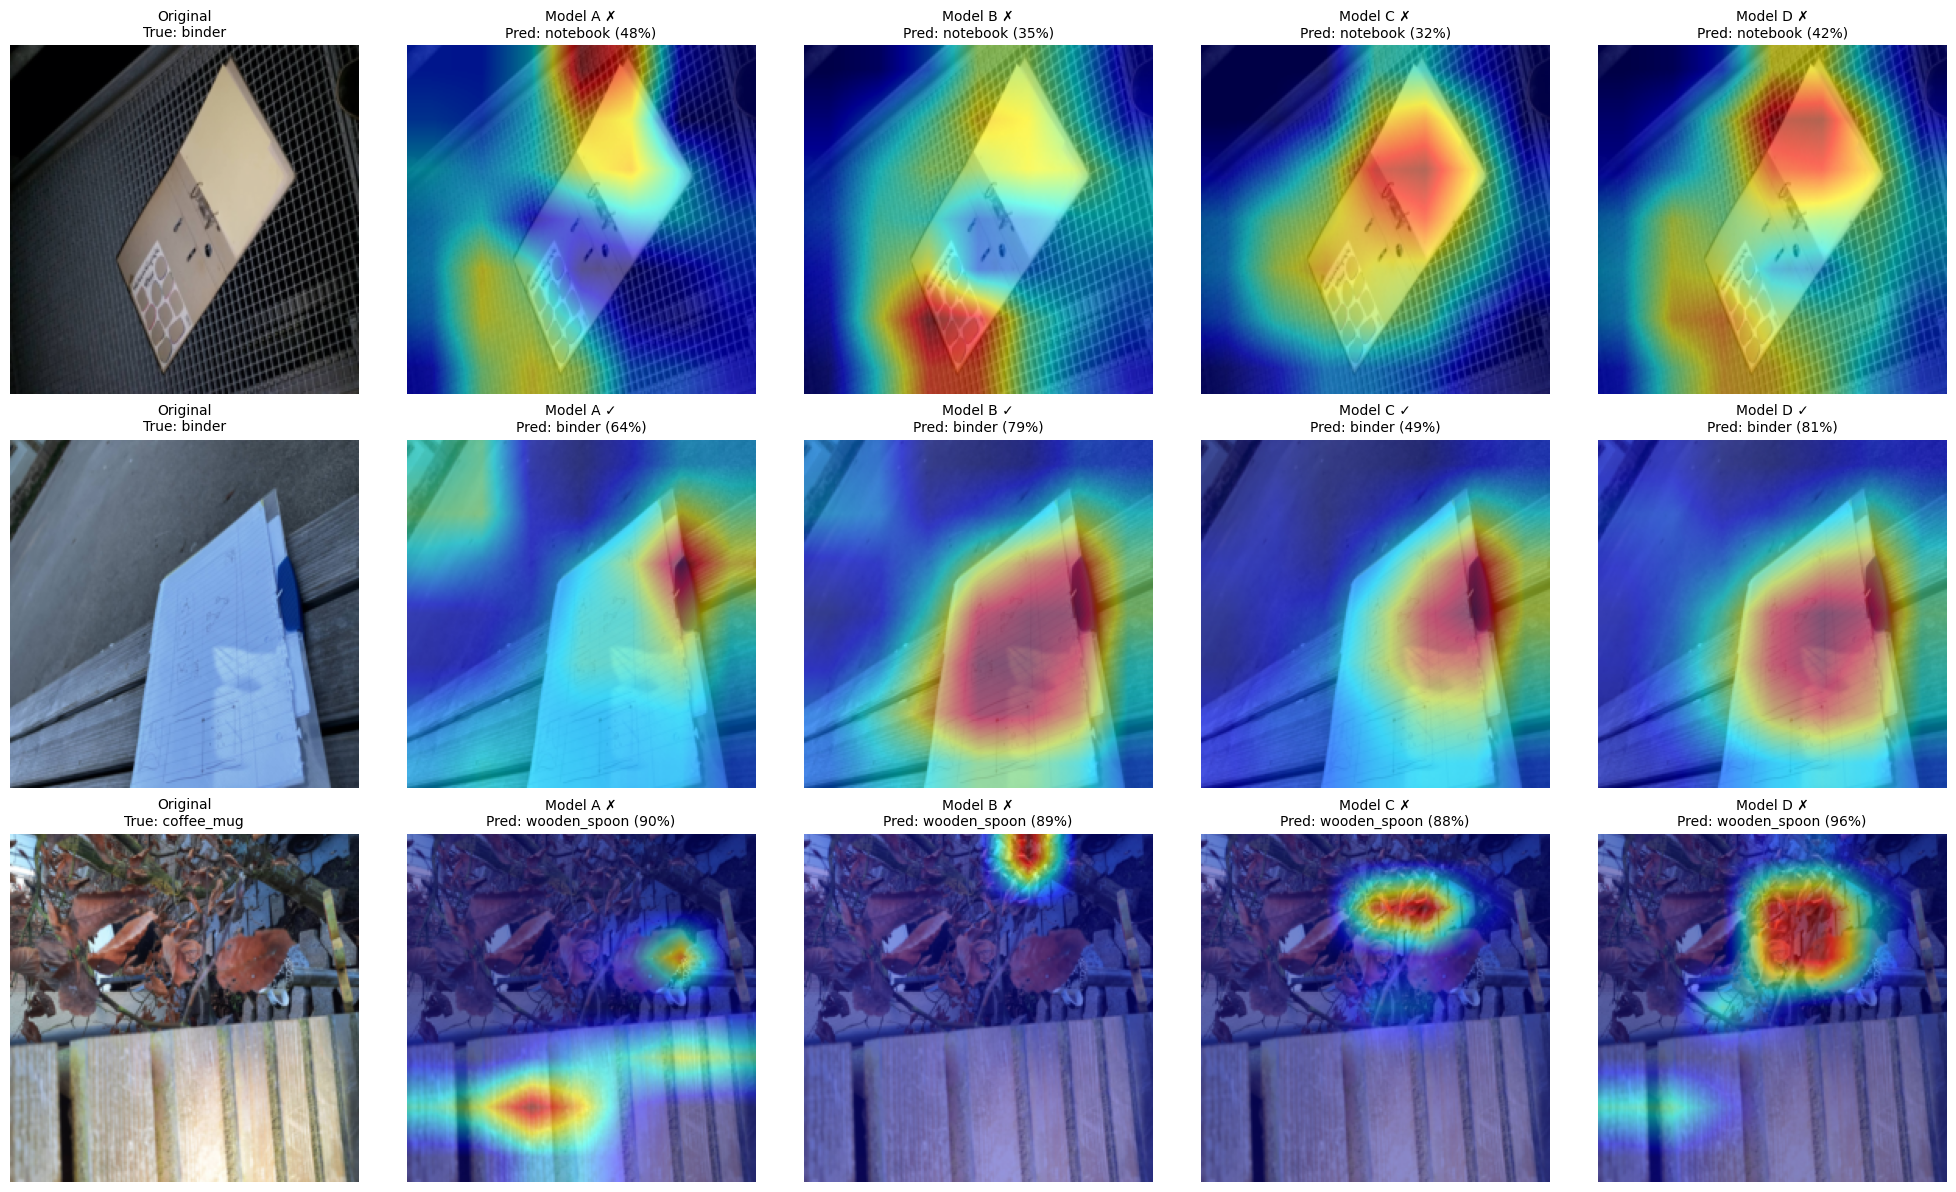

Grid saved to: ./gradcam_outputs/gradcam_comparison_grid.png

GRAD-CAM VISUALIZATION COMPLETE!
Individual images: C:\Users\Elahe\Desktop\Repo-xAI-Proj-B\block-4-5-model-ab-fatemeh\notebooks\gradcam_outputs
Comparison grid:   C:\Users\Elahe\Desktop\Repo-xAI-Proj-B\block-4-5-model-ab-fatemeh\notebooks\gradcam_outputs/gradcam_comparison_grid.png

Interpretation:
  - Red/Yellow = High importance (model focuses here)
  - Blue/Green = Low importance
  - ✓ = Correct, ✗ = Wrong prediction


In [20]:
# Block 10 - Grad-CAM Explainability on Test Set
# ============================================================================
# This block performs Grad-CAM visualization on the TEST SET.
#
# Grad-CAM (Gradient-weighted Class Activation Mapping):
#   - Shows which image regions the model focuses on for its prediction
#   - Red/Yellow = High importance | Blue/Green = Low importance
# ============================================================================

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from torchvision import datasets, transforms
import torch

# ============ HELPER FUNCTIONS ============
def unnormalize_image(img_tensor):
    """Reverse ImageNet normalization to get original image."""
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = img_tensor.cpu().numpy()
    img = (img * std[:, None, None]) + mean[:, None, None]
    img = np.clip(img, 0, 1)
    img = np.transpose(img, (1, 2, 0))  # [H,W,3]
    return img

def save_gradcam_overlay(img_tensor, cam_mask, out_path, title=""):
    """Save Grad-CAM overlay image to file."""
    img = unnormalize_image(img_tensor)
    cam_overlay = show_cam_on_image(img, cam_mask, use_rgb=True)
    
    plt.figure(figsize=(5, 5))
    plt.imshow(cam_overlay)
    plt.axis('off')
    plt.title(title, fontsize=9)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.close()

def display_gradcam_grid(test_dataset, models_dict, indices, device, class_names):
    """Display Grad-CAM results in a grid (inline in notebook)."""
    n_images = len(indices)
    n_models = len(models_dict)
    
    if n_models == 0 or n_images == 0:
        print("No models or images to display.")
        return
    
    fig, axes = plt.subplots(n_images, n_models + 1, figsize=(4*(n_models+1), 4*n_images))
    
    if n_images == 1:
        axes = [axes]
    
    for row, idx in enumerate(indices):
        if idx >= len(test_dataset):
            continue
            
        x, y = test_dataset[idx]
        img = unnormalize_image(x)
        true_name = class_names[y]
        
        axes[row][0].imshow(img)
        axes[row][0].set_title(f"Original\nTrue: {true_name}", fontsize=10)
        axes[row][0].axis('off')
        
        for col, (model_key, model) in enumerate(models_dict.items(), start=1):
            model.eval()
            model = model.to(device)
            target_layer = model.layer4[-1]
            
            # Enable gradients for Grad-CAM
            for param in model.parameters():
                param.requires_grad = True
            
            x_b = x.unsqueeze(0).to(device)
            
            with GradCAM(model=model, target_layers=[target_layer]) as cam:
                targets = [ClassifierOutputTarget(y)]
                cam_map = cam(input_tensor=x_b, targets=targets)
            
            with torch.no_grad():
                logits = model(x_b)
                probs = torch.softmax(logits, dim=1)[0]
                pred = int(probs.argmax().item())
                conf = float(probs.max().item())
            
            pred_name = class_names[pred]
            correct = "✓" if pred == y else "✗"
            
            cam_overlay = show_cam_on_image(img, cam_map[0], use_rgb=True)
            
            axes[row][col].imshow(cam_overlay)
            axes[row][col].set_title(f"Model {model_key} {correct}\nPred: {pred_name} ({conf*100:.0f}%)", fontsize=10)
            axes[row][col].axis('off')
    
    plt.tight_layout()
    plt.savefig("./gradcam_outputs/gradcam_comparison_grid.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Grid saved to: ./gradcam_outputs/gradcam_comparison_grid.png")

# ============ FIND TEST DATASET PATH ============
print("="*60)
print("BLOCK 10: GRAD-CAM EXPLAINABILITY")
print("="*60)

# Try multiple possible paths
# Test dataset path (relative to notebooks folder)
test_dir = Path("./data/xAI_ImageNet1k_OwnTestSet/xai-imagenet10-hard-test")


if not test_dir.exists():
    print("❌ Test directory not found!")

# ============ LOAD TEST DATASET ============
input_size = 224
test_transform = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

if test_dir.exists():
    test_dataset = datasets.ImageFolder(test_dir, test_transform)
    test_class_names = test_dataset.classes
    print(f"✅ Test dataset loaded: {len(test_dataset)} images")
    print(f"   Classes: {test_class_names}")
else:
    test_dataset = None
    test_class_names = []

# ============ CHECK DEVICE ============
# 'device' is already defined in the notebook, so we skip redefining it here.

# ============ DEFINE MODELS TO EXPLAIN ============
models_to_explain = {}

if 'model_A' in globals() and model_A is not None:
    models_to_explain['A'] = model_A
if 'model_B' in globals() and model_B is not None:
    models_to_explain['B'] = model_B
if 'model_C' in globals() and model_C is not None:
    models_to_explain['C'] = model_C
if 'model_D' in globals() and model_D is not None:
    models_to_explain['D'] = model_D

print(f"\nModels available for Grad-CAM: {list(models_to_explain.keys())}")

# ============ GRAD-CAM VISUALIZATION ============
if test_dataset is not None and len(models_to_explain) > 0:

    OUT_DIR = Path("./gradcam_outputs")
    OUT_DIR.mkdir(exist_ok=True)

    indices_to_viz = [0, 100, 500, 1000, 2000]
    indices_to_viz = [i for i in indices_to_viz if i < len(test_dataset)]

    print(f"\n{'='*60}")
    print(f"Generating Grad-CAM for {len(indices_to_viz)} test images...")
    print(f"Output directory: {OUT_DIR.resolve()}")
    print(f"{'='*60}\n")

    print("Part 1: Saving individual Grad-CAM images...")
    
    for key, model in models_to_explain.items():
        print(f"  Processing Model {key}...")
        model.eval()
        model = model.to(device)
        target_layer = model.layer4[-1]
        
        # Enable gradients for Grad-CAM (required for frozen models like A and C)
        for param in model.parameters():
            param.requires_grad = True

        with GradCAM(model=model, target_layers=[target_layer]) as cam_engine:
            for idx in indices_to_viz:
                x, y = test_dataset[idx]
                x_b = x.unsqueeze(0).to(device)

                targets = [ClassifierOutputTarget(y)]
                cam_map = cam_engine(input_tensor=x_b, targets=targets)

                with torch.no_grad():
                    logits = model(x_b)
                    probs = torch.softmax(logits, dim=1)[0]
                    pred = int(probs.argmax().item())
                    conf = float(probs.max().item())

                true_name = test_class_names[y]
                pred_name = test_class_names[pred]
                correct = "✓" if pred == y else "✗"

                title = f"Model {key} | {correct} | True: {true_name} | Pred: {pred_name} ({conf*100:.1f}%)"
                filename = f"gradcam_M{key}_idx{idx}_{true_name}_pred_{pred_name}.png"
                out_path = OUT_DIR / filename

                save_gradcam_overlay(x, cam_map[0], out_path, title=title)

    print(f"  Saved {len(indices_to_viz) * len(models_to_explain)} individual images.\n")

    print("Part 2: Generating comparison grid...")
    grid_indices = indices_to_viz[:3]
    
    display_gradcam_grid(
        test_dataset=test_dataset,
        models_dict=models_to_explain,
        indices=grid_indices,
        device=device,
        class_names=test_class_names
    )

    print(f"\n{'='*60}")
    print("GRAD-CAM VISUALIZATION COMPLETE!")
    print(f"{'='*60}")
    print(f"Individual images: {OUT_DIR.resolve()}")
    print(f"Comparison grid:   {OUT_DIR.resolve()}/gradcam_comparison_grid.png")
    print(f"\nInterpretation:")
    print("  - Red/Yellow = High importance (model focuses here)")
    print("  - Blue/Green = Low importance")
    print("  - ✓ = Correct, ✗ = Wrong prediction")
    print(f"{'='*60}")

else:
    print("\n" + "="*60)
    print("CANNOT RUN GRAD-CAM")
    print("="*60)
    if test_dataset is None:
        print("❌ Test dataset not found.")
    if len(models_to_explain) == 0:
        print("❌ No trained models found.")
        print("   Please run Block 8 or Block 8.5 first.")
    print("="*60)

---

## Quick Reference - Execution Order

| Block | Name | Run When |
|-------|------|----------|
| 0 | Imports & Setup | **EVERY TIME** (after kernel restart) |
| 1 | Dataset Loading | **EVERY TIME** (after kernel restart) |
| 2 | Training Function | **EVERY TIME** (after kernel restart) |
| 2.5 | Test Evaluation Function | **EVERY TIME** (after kernel restart) |
| 3 | Flower Documentation | READ ONLY |
| 4 | Model A Definition | **EVERY TIME** (after kernel restart) |
| 5 | Model B Definition | **EVERY TIME** (after kernel restart) |
| 6 | Model C Definition | **EVERY TIME** (after kernel restart) |
| 7 | Model D Definition | **EVERY TIME** (after kernel restart) |
| 8 | Train All Models | **ONCE** (takes 30-60 min) - First time only |
| **8.5** | **Load Saved Models** | **USE THIS** after first training (fast!) |
| 9 | Test Evaluation | **AFTER TRAINING or LOADING** |
| 10 | Grad-CAM Explainability | **AFTER TRAINING or LOADING** |

---

## Two Workflows:

### First Time (Training):
```
Restart kernel → Run 0-7 → Run Block 8 (train) → Run 9, 10
```

### After First Time (Load Saved Models):
```
Restart kernel → Run 0-7 → Run Block 8.5 (load) → Run 9, 10
```

**Block 8.5 loads models in seconds instead of 30-60 minutes!**